# Node classification via recommendation systems algorithem (REV2)

## imports

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from scipy.special import expit
from scipy.stats import kendalltau
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    classification_report,
)

warnings.filterwarnings("ignore", category=UserWarning)

for env_path in [Path.cwd() / ".env", Path.cwd().parent / ".env", Path.cwd().parent.parent / ".env"]:
    if env_path.exists():
        load_dotenv(env_path)
        print("Loaded .env from:", env_path.resolve())
        break

def project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, cwd.parent, cwd.parent.parent]:
        if (p / "ETL").is_dir():
            return p
    return cwd.parent.parent

ROOT = project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ETL.gnn_db_pipeline.config import (
    TARGET_DB,
    TGT_CHANGED_HOLDINGS,
    TGT_CHANGED_STAS,
    TGT_CIK_AUM,
    TGT_STOCKS_RETURN,
)
from ETL.gnn_db_pipeline.db_connector import ConfigurablePostgresHandler

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)

handler = ConfigurablePostgresHandler(TARGET_DB)
handler.connect()
print("Connected to", TARGET_DB)

2026-04-21 10:34:32 - ETL_Pipeline - INFO - Connected to PostgreSQL: postgres@127.0.0.1:5432/13FGNN


Loaded .env from: C:\Users\potda\Daniel\BGU\Year_D\סמסטר ז\Final_Project\Social-Network-Stock-Market\.env
Deleted old log file: logs\etl_pipeline_20260418_220613.log
Deleted old log file: logs\etl_pipeline_20260418_215754.log
Deleted old log file: logs\etl_pipeline_20260418_191736.log
Connected to 13FGNN


## Config

In [2]:
# Target quarter
YEAR, QUARTER = 2016, 3

# REV2 hyperparameters (paper defaults)
GAMMA1 = 1
GAMMA2 = 1
MAX_ITER = 100
TOL = 1e-6

CLASS_NAMES = ["low", "mid", "high"]

## Data Loaders

In [14]:
def load_edges(year: int, quarter: int) -> pd.DataFrame:
    """Δ-graph edges: (cik, cusip, w=change_in_weight) for one quarter."""
    q = f"""
        SELECT cik, cusip, change_in_weight AS w
        FROM {TGT_CHANGED_HOLDINGS}
        WHERE year = %s AND quarter = %s AND change_in_weight IS NOT NULL
    """
    return handler.query(q, (year, quarter))

def load_edges_adjusted(year: int, quarter: int) -> pd.DataFrame:
    """Δ-graph edges: (cik, cusip, w=change_in_weight) for one quarter."""
    q = f"""
        SELECT cik, cusip, change_in_adjusted_weight AS w
        FROM {TGT_CHANGED_HOLDINGS}
        WHERE year = %s AND quarter = %s AND change_in_weight IS NOT NULL
    """
    return handler.query(q, (year, quarter))


def load_cusip_to_ticker(year: int, quarter: int) -> pd.DataFrame:
    """map cusip to ticker"""
    q = f"""
        SELECT cusip, ticker , name
        FROM ticker_to_cusip
    """
    return handler.query(q)


def load_returns(year: int, quarter: int) -> pd.DataFrame:
    """Per-stock log-return for the quarter."""
    q = f"""
        SELECT cusip, log_return
        FROM {TGT_STOCKS_RETURN}
        WHERE year = %s AND quarter = %s AND log_return IS NOT NULL
    """
    return handler.query(q, (year, quarter))


def load_aum(year: int, quarter: int) -> pd.Series:
    """Per-CIK AUM (total portfolio value) for the quarter, indexed by cik."""
    q = f"""
        SELECT cik, total AS aum
        FROM {TGT_CIK_AUM}
        WHERE year = %s AND quarter = %s AND total > 0
    """
    df = handler.query(q, (year, quarter))
    return df.set_index("cik")["aum"]


def load_tertile_bounds(year: int, quarter: int):
    q = f"""
        SELECT log_return_tertile_1, log_return_tertile_2
        FROM {TGT_CHANGED_STAS}
        WHERE year = %s AND quarter = %s
    """
    row = handler.query(q, (year, quarter)).iloc[0]
    return float(row["log_return_tertile_1"]), float(row["log_return_tertile_2"])


def label_stocks(year: int, quarter: int) -> pd.DataFrame:
    """Assign each stock a tertile label {0, 1, 2} via pre-computed cutoffs."""
    rets = load_returns(year, quarter)
    t1, t2 = load_tertile_bounds(year, quarter)
    rets = rets.copy()
    rets["true_class"] = np.where(
        rets["log_return"] <= t1, 0,
        np.where(rets["log_return"] <= t2, 1, 2),
    )
    return rets[["cusip", "log_return", "true_class"]]

## Pre-flight sanity check

=== 2016 Q3 ===
Edges:              756,323
Unique CIKs:        3,905
Unique CUSIPs:      2,964
CIKs with AUM:      3,963
CIKs w/o AUM match: 0

change_in_weight describe:
count    7.563230e+05
mean     1.328322e-18
std      1.702982e-02
min     -1.000000e+00
25%     -7.334137e-05
50%      2.361417e-07
75%      8.474720e-05
max      1.000000e+00
Name: w, dtype: float64

Tertile bounds:  t1=0.0120  t2=0.1237
Label distribution:
true_class
low     1036
mid     1036
high    1036
Name: count, dtype: int64


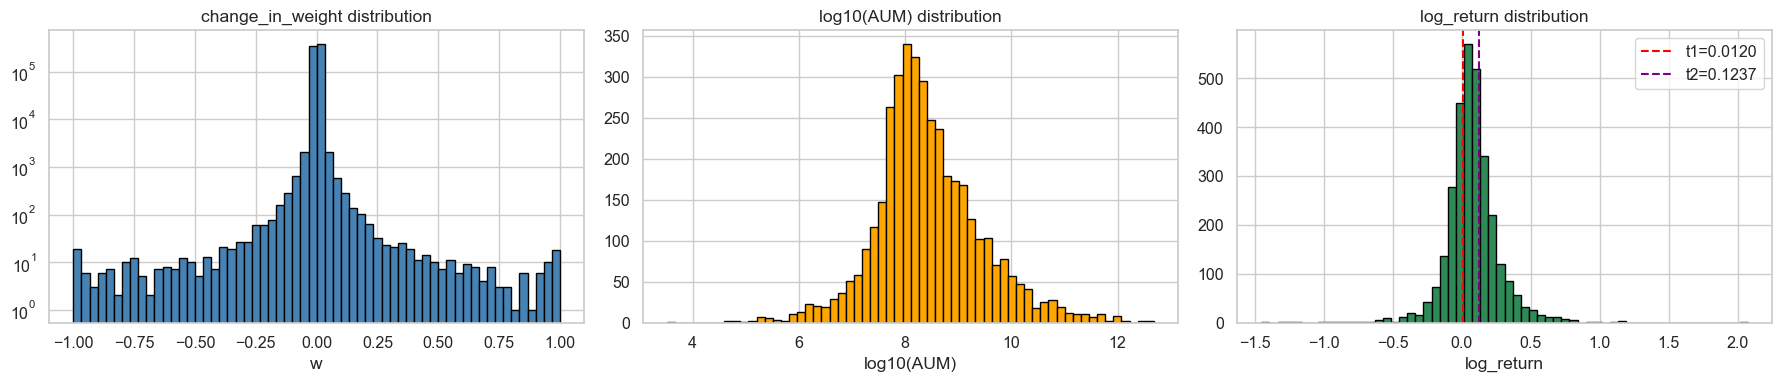

In [15]:
edges = load_edges(YEAR, QUARTER)
aum = load_aum(YEAR, QUARTER)
labels = label_stocks(YEAR, QUARTER)
t1, t2 = load_tertile_bounds(YEAR, QUARTER)
t2c = load_cusip_to_ticker(YEAR, QUARTER)

print(f"=== {YEAR} Q{QUARTER} ===")
print(f"Edges:              {len(edges):,}")
print(f"Unique CIKs:        {edges['cik'].nunique():,}")
print(f"Unique CUSIPs:      {edges['cusip'].nunique():,}")
print(f"CIKs with AUM:      {aum.shape[0]:,}")
missing_aum = edges.loc[~edges['cik'].isin(aum.index), 'cik'].nunique()
print(f"CIKs w/o AUM match: {missing_aum}")
print()
print("change_in_weight describe:")
print(edges["w"].describe())
print()
print(f"Tertile bounds:  t1={t1:.4f}  t2={t2:.4f}")
print("Label distribution:")
print(labels["true_class"].value_counts().sort_index().rename(index={0:"low",1:"mid",2:"high"}))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(edges["w"], bins=60, color="steelblue", edgecolor="black")
axes[0].set_title("change_in_weight distribution")
axes[0].set_xlabel("w")
axes[0].set_yscale("log")
axes[1].hist(np.log10(aum.values), bins=60, color="orange", edgecolor="black")
axes[1].set_title("log10(AUM) distribution")
axes[1].set_xlabel("log10(AUM)")
axes[2].hist(labels["log_return"], bins=60, color="seagreen", edgecolor="black")
axes[2].axvline(t1, color='red', linestyle='--', label=f't1={t1:.4f}')
axes[2].axvline(t2, color='purple', linestyle='--', label=f't2={t2:.4f}')
axes[2].set_title("log_return distribution")
axes[2].set_xlabel("log_return")
axes[2].legend()
plt.tight_layout()
plt.show()

In [5]:
edges.head()

,cik,cusip,w
0,0001434323,00206R102,-0.000414
1,0000884541,907818108,0.000180
2,0000884541,911163103,-0.007308
3,0000884541,911312106,-0.001162
4,0000884541,91324P102,-0.000022


In [6]:
aum.head()

cik
0000002230    9.963093e+08
0000003520    1.182860e+10
0000005272    4.593959e+10
0000007195    1.665470e+08
0000007789    9.161325e+08
Name: aum, dtype: float64

In [7]:
labels.head()

,cusip,log_return,true_class
0,000307108,-0.271742,0
1,000360206,0.046519,1
2,000361105,0.297189,2
3,00081T108,-0.069133,0
4,000868109,0.064362,1


## 4.2 Baseline — `G(p) = mean(w)` over `In(p)`

In [10]:
def goodness_baseline(edges: pd.DataFrame) -> pd.DataFrame:
    g = edges.groupby("cusip", as_index=False)["w"].mean().rename(columns={"w": "G"})
    return g

In [18]:
print("Top 25 stocks by G (baseline) with name and ticker:")

g_base = goodness_baseline(edges)
top_g_base = g_base.sort_values("G", ascending=False).head(25)

# Assume `t2c` is a dataframe already loaded with columns: cusip, ticker, name
top_g_base = top_g_base.merge(t2c[["cusip", "ticker", "name"]], on="cusip", how="left")
print(top_g_base[["cusip", "ticker", "name", "G"]])

Top 25 stocks by G (baseline) with name and ticker:
        cusip ticker                                 name         G
0   053734109   AVGR                          Avinger Inc  0.061462
1   630104107     NH                       NantHealth Inc  0.059013
2   00773J103   SYRE           Aeglea BioTherapeutics Inc  0.047245
3   g3164q101  CJESQ              C&J Energy Services Ltd  0.036890
4   90041L105    TPB             Turning Point Brands Inc  0.031351
5   369604301     GE                  General Electric Co  0.030698
6   46186M209  NVIVQ    InVivo Therapeutics Holdings Corp  0.028579
7   45782B104   INSG                         Inseego Corp  0.022363
8   21833P103   CRBP  Corbus Pharmaceuticals Holdings Inc  0.022165
9   03835C108   APTI                           Apptio Inc  0.019335
10  826917106   SIGA                SIGA Technologies Inc  0.017389
11  00401C108   ACIA            Acacia Communications Inc  0.016638
12  00507W107   ATNM         Actinium Pharmaceuticals Inc  0.015

## 4.3 REV2 — iterative F / R / G

```
R(u,p) = (γ1·F(u) + γ2·(1 − |w(u,p) − G(p)|/2)) / (γ1+γ2)
G(p)   = mean_u  R(u,p) · w(u,p)
F(u)   = mean_p  R(u,p)
```

**AUM-init variant:** replace neutral `F₀(u) = 0.5` with `sigmoid(z_score(log AUM_u))`. Updates otherwise identical.

In [19]:
def _init_fairness_aum(ciks: pd.Index, aum: pd.Series) -> pd.Series:
    """F₀(u) = sigmoid((log AUM_u − μ) / σ).  Users w/o AUM fall back to 0.5."""
    log_aum = np.log(aum.reindex(ciks))
    mu, sigma = log_aum.mean(), log_aum.std()
    z = (log_aum - mu) / sigma if sigma > 0 else log_aum * 0
    f0 = pd.Series(expit(z.values), index=ciks)
    f0 = f0.fillna(0.5)
    return f0


def goodness_rev2(
    edges: pd.DataFrame,
    gamma1: float = 1.0,
    gamma2: float = 1.0,
    max_iter: int = 100,
    tol: float = 1e-6,
    aum: pd.Series | None = None,
    verbose: bool = True,
):
    """Iterate REV2 to convergence on a single-quarter edge list.

    Returns (F_series, G_series, history).
    If `aum` is provided, F₀ is AUM-based; otherwise F₀ = 0.5.
    """
    E = edges[["cik", "cusip", "w"]].copy()
    ciks = pd.Index(E["cik"].unique(), name="cik")
    cusips = pd.Index(E["cusip"].unique(), name="cusip")

    if aum is not None:
        F = _init_fairness_aum(ciks, aum)
    else:
        F = pd.Series(0.5, index=ciks)
    G = pd.Series(0.0, index=cusips)

    denom = gamma1 + gamma2
    history = []

    for it in range(1, max_iter + 1):
        # R(u,p) using current F, G
        f_u = E["cik"].map(F).to_numpy()
        g_p = E["cusip"].map(G).to_numpy()
        agreement = 1.0 - np.abs(E["w"].to_numpy() - g_p) / 2.0
        E["R"] = (gamma1 * f_u + gamma2 * agreement) / denom

        # G(p) = mean_u  R(u,p) · w(u,p)
        E["RW"] = E["R"] * E["w"]
        G_new = E.groupby("cusip")["RW"].mean().reindex(cusips).fillna(0.0)

        # F(u) = mean_p R(u,p)
        F_new = E.groupby("cik")["R"].mean().reindex(ciks).fillna(0.5)

        delta_G = float(np.max(np.abs(G_new.values - G.values)))
        delta_F = float(np.max(np.abs(F_new.values - F.values)))
        history.append({"iter": it, "delta_G": delta_G, "delta_F": delta_F})

        F, G = F_new, G_new
        if delta_G < tol and delta_F < tol:
            if verbose:
                print(f"REV2 converged at iter {it}  |  ΔG={delta_G:.2e}  ΔF={delta_F:.2e}")
            break
    else:
        if verbose:
            print(f"REV2 hit max_iter={max_iter}  |  ΔG={delta_G:.2e}  ΔF={delta_F:.2e}")

    hist_df = pd.DataFrame(history)
    return F, G, hist_df

## Evaluation utilities

In [21]:
def g_to_class(g_df: pd.DataFrame, g_col: str = "G") -> pd.DataFrame:
    """Cut predicted G into tertiles -> class 0/1/2."""
    out = g_df.copy()
    out["pred_class"] = pd.qcut(out[g_col], 3, labels=[0, 1, 2], duplicates="drop").astype(int)
    return out


def evaluate(g_df: pd.DataFrame, labels: pd.DataFrame, g_col: str = "G") -> dict:
    pred = g_to_class(g_df, g_col=g_col)
    m = pred.merge(labels, on="cusip", how="inner")
    if m.empty:
        return {"n_stocks": 0}
    tau = kendalltau(m[g_col], m["log_return"]).statistic
    return {
        "n_stocks": len(m),
        "accuracy": accuracy_score(m["true_class"], m["pred_class"]),
        "macro_f1": f1_score(m["true_class"], m["pred_class"], average="macro"),
        "kendall_tau": tau,
        "confusion": confusion_matrix(m["true_class"], m["pred_class"], labels=[0, 1, 2]),
        "merged": m,
    }


def plot_confusion(cm: np.ndarray, title: str, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cbar=False,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

## Run all three on the target quarter

In [22]:
# 4.2 baseline
G_base = goodness_baseline(edges)
metrics_base = evaluate(G_base, labels)

# 4.3 REV2 vanilla
F_rev2, G_rev2, hist_rev2 = goodness_rev2(edges, gamma1=GAMMA1, gamma2=GAMMA2,
                                           max_iter=MAX_ITER, tol=TOL, aum=None)
metrics_rev2 = evaluate(G_rev2.rename("G").reset_index(), labels)

# 4.3 REV2 + AUM init
F_aum, G_aum, hist_aum = goodness_rev2(edges, gamma1=GAMMA1, gamma2=GAMMA2,
                                        max_iter=MAX_ITER, tol=TOL, aum=aum)
metrics_aum = evaluate(G_aum.rename("G").reset_index(), labels)

summary = pd.DataFrame(
    [
        {"method": "baseline",      **{k: metrics_base[k] for k in ("n_stocks","accuracy","macro_f1","kendall_tau")}, "n_iter": None},
        {"method": "rev2",          **{k: metrics_rev2[k] for k in ("n_stocks","accuracy","macro_f1","kendall_tau")}, "n_iter": len(hist_rev2)},
        {"method": "rev2_aum_init", **{k: metrics_aum[k]  for k in ("n_stocks","accuracy","macro_f1","kendall_tau")}, "n_iter": len(hist_aum)},
    ]
)
summary

REV2 converged at iter 19  |  ΔG=6.46e-08  ΔF=9.77e-07
REV2 converged at iter 20  |  ΔG=2.77e-08  ΔF=9.32e-07


,method,n_stocks,accuracy,macro_f1,kendall_tau,n_iter
0,baseline,2893,0.519530,0.520328,0.338716,NaN
1,rev2,2893,0.521604,0.522409,0.344527,19.0
2,rev2_aum_init,2893,0.521604,0.522409,0.344527,20.0


## Confusion matrices

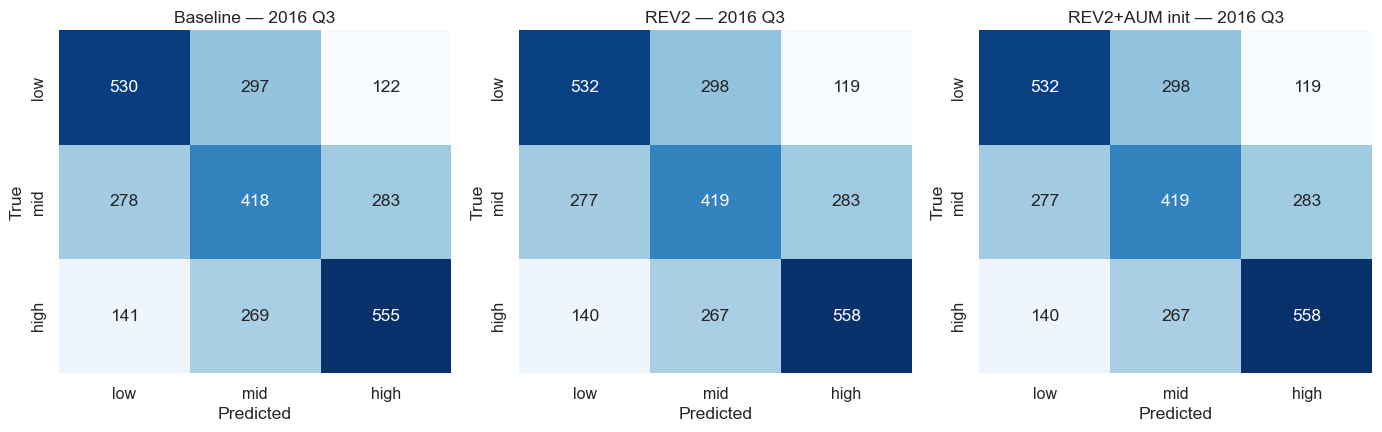

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
plot_confusion(metrics_base["confusion"], f"Baseline — {YEAR} Q{QUARTER}", axes[0])
plot_confusion(metrics_rev2["confusion"], f"REV2 — {YEAR} Q{QUARTER}",     axes[1])
plot_confusion(metrics_aum["confusion"],  f"REV2+AUM init — {YEAR} Q{QUARTER}", axes[2])
plt.tight_layout()
plt.show()

## REV2 convergence trace

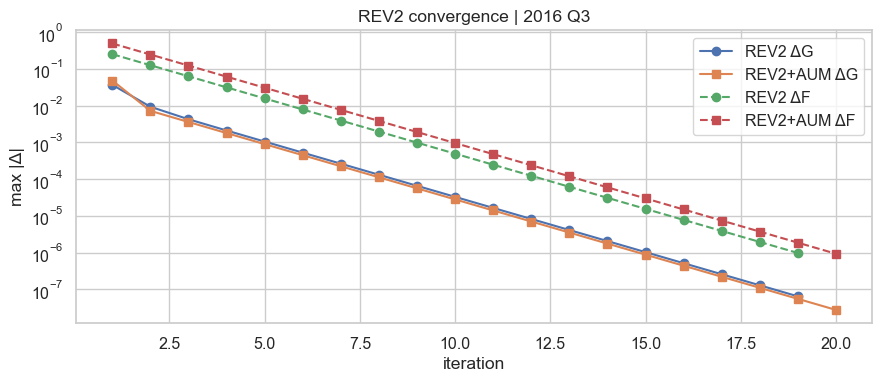

In [24]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hist_rev2["iter"], hist_rev2["delta_G"], marker="o", label="REV2 ΔG")
ax.plot(hist_aum["iter"],  hist_aum["delta_G"],  marker="s", label="REV2+AUM ΔG")
ax.plot(hist_rev2["iter"], hist_rev2["delta_F"], marker="o", linestyle="--", label="REV2 ΔF")
ax.plot(hist_aum["iter"],  hist_aum["delta_F"],  marker="s", linestyle="--", label="REV2+AUM ΔF")
ax.set_yscale("log")
ax.set_xlabel("iteration")
ax.set_ylabel("max |Δ|")
ax.set_title(f"REV2 convergence | {YEAR} Q{QUARTER}")
ax.legend()
plt.tight_layout()
plt.show()

## Top / bottom stocks per method

In [26]:
def show_ranked(g_series: pd.Series, labels: pd.DataFrame, t2c: pd.DataFrame, n: int = 10, name: str = "G"):
    # Merge G-series with labels (should have 'cusip')
    df = g_series.rename(name).reset_index().merge(labels, on="cusip", how="inner")
    # Merge to bring in 'name' and 'ticker' from t2c using 'cusip'
    df = df.merge(t2c[["cusip", "name", "ticker"]], on="cusip", how="left")
    df = df.sort_values(name, ascending=False)
    print(f"--- Top {n} by {name} ---")
    print(df.head(n).to_string(index=False))
    print(f"--- Bottom {n} by {name} ---")
    print(df.tail(n).to_string(index=False))

print("=== REV2 + AUM init ===")
show_ranked(G_aum, labels, t2c, n=10, name="G")

=== REV2 + AUM init ===
--- Top 10 by G ---
    cusip        G  log_return  true_class                                name ticker
053734109 0.048587   -0.557917           0                         Avinger Inc   AVGR
g3164q101 0.036630    0.321168           2             C&J Energy Services Ltd  CJESQ
369604301 0.029703   -0.053128           0                 General Electric Co     GE
46186M209 0.026164    0.162519           2   InVivo Therapeutics Holdings Corp  NVIVQ
45782B104 0.022342    0.722323           2                        Inseego Corp   INSG
21833P103 0.017597    0.820178           2 Corbus Pharmaceuticals Holdings Inc   CRBP
826917106 0.017109    1.095375           2               SIGA Technologies Inc   SIGA
696077403 0.015177    0.358945           2            Palatin Technologies Inc    PTN
00507W107 0.013867   -0.270873           0        Actinium Pharmaceuticals Inc   ATNM
73640Q105 0.012183    0.358248           2   Portfolio Recovery Associates Inc   PRAA
--- Bottom

## Investor ranking (fairness F)

Bonus view: investors ranked by fairness under REV2+AUM init, joined with raw AUM to sanity-check that F isn't just ≈ AUM after convergence.

In [ ]:
inv = F_aum.rename("F").reset_index().merge(aum.rename("AUM").reset_index(), on="cik", how="left")
inv["log_AUM"] = np.log(inv["AUM"])
inv_sorted = inv.sort_values("F", ascending=False)
print("Top 15 investors by F (REV2+AUM init):")
print(inv_sorted.head(15).to_string(index=False))

tau_fa = kendalltau(inv["F"], inv["log_AUM"], nan_policy="omit").statistic
print(f"\nKendall τ(F, log_AUM) = {tau_fa:.4f}")
print("(high τ → F mostly tracks size; low τ → REV2 is learning something else on top)")

Top 15 investors by F (REV2+AUM init):
       cik        F          AUM   log_AUM
0001535859 0.999993 1.228494e+06 14.021300
0001279915 0.999991 1.259443e+08 18.651350
0001650318 0.999991 7.417036e+07 18.121875
0001600083 0.999985 2.848475e+08 19.467465
0000801166 0.999983 1.640745e+06 14.310661
0000943719 0.999972 1.099715e+08 18.515731
0001408700 0.999970 4.054718e+07 17.517977
0001623580 0.999969 1.528947e+08 18.845260
0001603935 0.999969 1.316768e+07 16.393276
0001595124 0.999950 2.560431e+07 17.058271
0001666860 0.999946 1.405245e+08 18.760892
0001023279 0.999941 1.009853e+07 16.127900
0001399486 0.999933 5.637826e+07 17.847594
0001521079 0.999932 1.667231e+08 18.931845
0001588225 0.999931 2.732867e+05 12.518277

Kendall τ(F, log_AUM) = 0.2079
(high τ → F mostly tracks size; low τ → REV2 is learning something else on top)
